In [1]:
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torch
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.utils import save_image
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import glob
import pandas as pd
from PIL import Image
%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
class CellImageDataset(Dataset):
    def __init__(self, imageFileList, labelFile):
        'Initialization'
        self.imageFileList =imageFileList
        
        self.transform = T.Compose([
            # T.ToPILImage(),
            # T.CenterCrop(0.75 * 64),
            # T.Resize(image_size),
            #T.RandomResizedCrop(image_size),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ToTensor()])
        
        df = pd.read_table(labelFile)
        df.dropna(axis=1, how='all', inplace=True) # Remove columns of all NaN
        df.dropna(inplace=True) # Drop rows containing NaN
        df = df[['Object ID']+df.columns[pd.Series(df.columns).str.startswith('xenium:cell_transcript:')].tolist()]
        df.set_index("Object ID", inplace = True)
        df.columns = [t.replace('xenium:cell_transcript:','') for t in df.columns.tolist()]
        
        self.geneData = df

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.imageFileList)
    
    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        imageFile = self.imageFileList[index]
        img = Image.open(imageFile)
        X = self.transform(img)
        return X
    



In [5]:
imageList = glob.glob('data/xenium/rep1/images/*/*.png', recursive=True)
labelFile = "data/xenium/rep1/singlecells.txt"

In [6]:
batch_size = 64
transformed_dataset = CellImageDataset(imageFileList=imageList, labelFile=labelFile)
training_data = DataLoader(transformed_dataset, batch_size, shuffle=True, num_workers=3, pin_memory=True)

In [7]:
def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid((images.detach()[:nmax]), nrow=8).permute(1, 2, 0))
def show_batch(dl, nmax=64):
    for images in dl:
        show_images(images, nmax)
        break

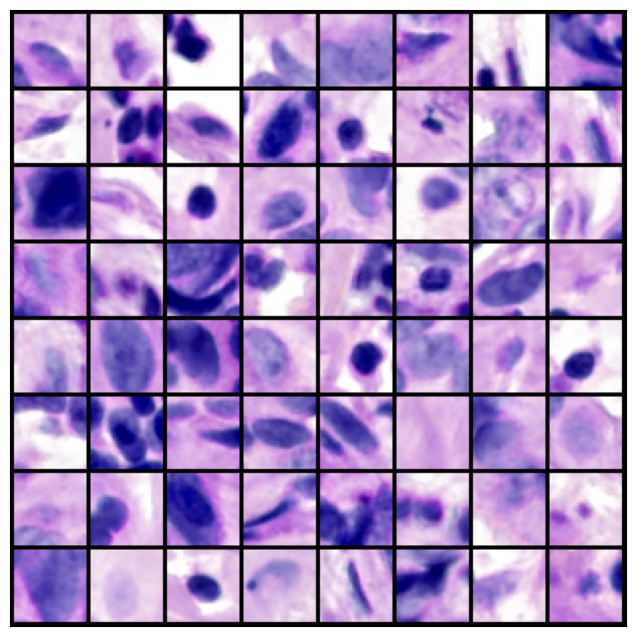

In [8]:
show_batch(train_dl)

In [9]:
from torch.utils.data import DataLoader
loaders = {
    'train' : torch.utils.data.DataLoader(train_dl, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}
loaders

NameError: name 'test_data' is not defined

In [ ]:
from torchvision import datasets
from torchvision.transforms import ToTensor 

In [ ]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.MNIST(
    root = 'data', 
    train = False, 
    transform = ToTensor()
)

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_data.data[0], cmap='gray')
plt.title('%i' % train_data.targets[0])
plt.show()

In [ ]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
loaders = {
    'train' : torch.utils.data.DataLoader(train_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}

In [ ]:
loaders

In [ ]:
import torch.nn as nn

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        
        self.out = nn.Linear(32 * 7 * 7, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        
        x = x.view(x.size(0), -1)     
        output = self.out(x)
        
        return output, x    # return x for visualization
    
    

In [ ]:
cnn = CNN()
print(cnn)

In [ ]:
loss_func = nn.CrossEntropyLoss()   
loss_func

In [ ]:
from torch import optim
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)   
optimizer

In [ ]:
from torch.autograd import Variable

In [ ]:
num_epochs = 10

def train(num_epochs, cnn, loaders):
    
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)   # batch y
            
            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()    
            # apply gradients             
            optimizer.step()                
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))



In [ ]:
train(num_epochs, cnn, loaders)

In [ ]:
def test():
    # Test the model
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in loaders['test']:
            test_output, last_layer = cnn(images)
            pred_y = torch.max(test_output, 1)[1].data.squeeze()
            accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
            print('Test Accuracy of the model on the 10000 test images: %.2f' % accuracy)


In [ ]:

test()

In [ ]:
sample = next(iter(loaders['test']))
imgs, lbls = sample


In [ ]:
actual_number = lbls[:10].numpy()
actual_number

In [ ]:
test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')